# Visualization of loops in contact maps in *A. rouxii* at 10 kb resolution

## Import libraries

In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl

In [2]:
# import cooltools and cooler
import cooltools
import cooler

In [3]:
# Import libraries for plotting
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cooltools.lib.plotting

from matplotlib.ticker import EngFormatter # For adding bp to plots
import matplotlib.patches as patches # For adding circles to the plots

## Set format for file

In [4]:
plt.rcParams['font.family'] = 'Times New Roman'

## Check available resolutions in mcool file and import the file at 10 kb resolution

In [5]:
# Resolutions in mcool file
cooler.fileops.list_coolers('/Users/emma/Documents/NMBU/Master/Master/Koding_python/ggAmyRoux1.mcool')

['/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/20000',
 '/resolutions/40000',
 '/resolutions/80000',
 '/resolutions/160000']

In [6]:
# Load the cool file at a specific resolution
res_10k = cooler.Cooler('/Users/emma/Documents/NMBU/Master/Master/Koding_python/ggAmyRoux1.mcool::resolutions/10000') 

# to print chromosome names and binsize for this cooler
print(f'chromosomes: {res_10k.chromnames}, binsize: {res_10k.binsize}')

chromosomes: ['subgenom1_SUPER_1', 'subgenom1_SUPER_2', 'subgenom1_SUPER_3', 'subgenom1_SUPER_4', 'subgenom1_SUPER_5', 'subgenom1_SUPER_6', 'subgenom1_SUPER_7', 'subgenom1_SUPER_8', 'subgenom1_SUPER_9', 'subgenom1_SUPER_10', 'subgenom1_Scaffold_23', 'subgenom1_Scaffold_25', 'subgenom1_Scaffold_26', 'subgenom1_Scaffold_27', 'subgenom1_Scaffold_28', 'subgenom1_Scaffold_39', 'subgenom1_Scaffold_40', 'subgenom1_Scaffold_21', 'subgenom1_MT', 'subgenom2_SUPER_2', 'subgenom2_SUPER_1', 'subgenom2_SUPER_3', 'subgenom2_SUPER_6', 'subgenom2_SUPER_9', 'subgenom2_SUPER_4', 'subgenom2_SUPER_5', 'subgenom2_SUPER_7', 'subgenom2_SUPER_8', 'subgenom2_SUPER_10', 'subgenom2_Scaffold_22', 'subgenom2_Scaffold_24', 'subgenom2_Scaffold_31', 'subgenom2_Scaffold_36'], binsize: 10000


In [7]:
# Makes a list of chromosomes and the bins for each chromosome. 
chromstarts = []
for i in res_10k.chromnames:
    print(f'{i} : {res_10k.extent(i)}')
    chromstarts.append(res_10k.extent(i)[0])

subgenom1_SUPER_1 : (0, 646)
subgenom1_SUPER_2 : (646, 1228)
subgenom1_SUPER_3 : (1228, 1700)
subgenom1_SUPER_4 : (1700, 2092)
subgenom1_SUPER_5 : (2092, 2475)
subgenom1_SUPER_6 : (2475, 2847)
subgenom1_SUPER_7 : (2847, 3178)
subgenom1_SUPER_8 : (3178, 3501)
subgenom1_SUPER_9 : (3501, 3784)
subgenom1_SUPER_10 : (3784, 4002)
subgenom1_Scaffold_23 : (4002, 4015)
subgenom1_Scaffold_25 : (4015, 4020)
subgenom1_Scaffold_26 : (4020, 4025)
subgenom1_Scaffold_27 : (4025, 4030)
subgenom1_Scaffold_28 : (4030, 4034)
subgenom1_Scaffold_39 : (4034, 4036)
subgenom1_Scaffold_40 : (4036, 4038)
subgenom1_Scaffold_21 : (4038, 4039)
subgenom1_MT : (4039, 4043)
subgenom2_SUPER_2 : (4043, 4646)
subgenom2_SUPER_1 : (4646, 5236)
subgenom2_SUPER_3 : (5236, 5700)
subgenom2_SUPER_6 : (5700, 6067)
subgenom2_SUPER_9 : (6067, 6431)
subgenom2_SUPER_4 : (6431, 6791)
subgenom2_SUPER_5 : (6791, 7148)
subgenom2_SUPER_7 : (7148, 7490)
subgenom2_SUPER_8 : (7490, 7804)
subgenom2_SUPER_10 : (7804, 8024)
subgenom2_Scaffold_

# Filtering out scaffolds from the Hi-C data

In [8]:
# Keep only chromosomes/scaffolds that are large enough
chroms_to_keep_10k = [c for c in res_10k.chromnames if "Scaffold" not in c and "MT" not in c]

print("Chromosomes kept:", chroms_to_keep_10k) # Print the chromosomes that we plot. 

Chromosomes kept: ['subgenom1_SUPER_1', 'subgenom1_SUPER_2', 'subgenom1_SUPER_3', 'subgenom1_SUPER_4', 'subgenom1_SUPER_5', 'subgenom1_SUPER_6', 'subgenom1_SUPER_7', 'subgenom1_SUPER_8', 'subgenom1_SUPER_9', 'subgenom1_SUPER_10', 'subgenom2_SUPER_2', 'subgenom2_SUPER_1', 'subgenom2_SUPER_3', 'subgenom2_SUPER_6', 'subgenom2_SUPER_9', 'subgenom2_SUPER_4', 'subgenom2_SUPER_5', 'subgenom2_SUPER_7', 'subgenom2_SUPER_8', 'subgenom2_SUPER_10']


In [9]:
# Find the bins for the chromosomes we are going to visualize and get the matrix for these chromosomes.

## Get the bins for the chromosomes we keep
bins_res_10k = res_10k.bins()[:]
keep_mask_res10k = bins_res_10k['chrom'].isin(chroms_to_keep_10k)

In [10]:
# Fetch full genome-wide matrix
full_matrix_res10k = res_10k.matrix(balance=False)[:]

# Subset matrix to only keep large chromosomes
matrix_filtered_res80k = full_matrix_res10k[keep_mask_res10k.values, :][:, keep_mask_res10k.values]

In [11]:
# Shorten the chromosome names so they only show the number of the chromosome.
chromstarts = []
pos = 0
short_labels = []
for c in chroms_to_keep_10k:
    n_bins = (bins_res_10k[bins_res_10k['chrom'] == c].shape[0])
    chromstarts.append(pos)
    short_labels.append(c.split('_')[-1])
    pos += n_bins

print(short_labels)

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '2', '1', '3', '6', '9', '4', '5', '7', '8', '10']


Used formatting code from cooltools tutorial: [https://cooltools.readthedocs.io/en/latest/notebooks/viz.html](https://cooltools.readthedocs.io/en/latest/notebooks/viz.html)

In [12]:
# Plots ticks as megabases
bp_formatter = EngFormatter('b')

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_top()  # move x ticks to top for genome plots
    if rotate:
        ax.tick_params(axis='x')

# Import loop file generated by Mustache

Loops were called at 10 kb resolution using Mustache with the parameters, p-threshold of 0.05 and sparsity-threshold of 0.8

## Importing and processing the loop file

In [13]:
loops_raw_10k = pd.read_csv(
    "/Users/emma/mustache/A_rouxii_loop10kb.p0_05.tsv",
    sep="\t",
    header=0  # Has header with BIN1_CHR, BIN1_START, BIN1_END, BIN2_CHROMOSOME, BIN2_START, BIN2_END, FDR and DETECTION_SCALE
)
# Select the coloumns we need
# BIN1_CHR, BIN1_START, BIN1_END, BIN2_CHROMOSOME, BIN2_START, BIN2_END, FDR
loops_10k = loops_raw_10k[["BIN1_CHR", "BIN1_START", "BIN1_END", "BIN2_CHROMOSOME", "BIN2_START", "BIN2_END", "FDR"]].copy()


# Rename columns to standard BEDPE format 
loops_10k_bedpe = loops_10k.rename(columns={
    "BIN1_CHR": "chrom1",
    "BIN1_START": "start1",
    "BIN1_END": "end1",
    "BIN2_CHROMOSOME": "chrom2",
    "BIN2_START": "start2",
    "BIN2_END": "end2"
})

print(loops_10k_bedpe.head())
print(loops_10k_bedpe.shape) # To see the size, 14 rows and 7 columns.

              chrom1   start1     end1             chrom2   start2     end2  \
0  subgenom1_SUPER_5  2210000  2220000  subgenom1_SUPER_5  2320000  2330000   
1  subgenom1_SUPER_6  2450000  2460000  subgenom1_SUPER_6  2640000  2650000   
2  subgenom1_SUPER_7  2350000  2360000  subgenom1_SUPER_7  2700000  2710000   
3  subgenom1_SUPER_7  2700000  2710000  subgenom1_SUPER_7  2910000  2920000   
4  subgenom1_SUPER_7  2910000  2920000  subgenom1_SUPER_7  3210000  3220000   

            FDR  
0  5.018425e-03  
1  2.751823e-03  
2  9.887259e-04  
3  2.101395e-07  
4  9.498713e-07  
(14, 7)


## Find size and mean size of loops

In [14]:
# Find size of loop using start positions
loops_10k_bedpe['loop_size'] = loops_10k_bedpe['start2'] - loops_10k_bedpe['start1']

# Convert loop size to kb
loops_10k_bedpe['loop_size_kb'] = loops_10k_bedpe['loop_size'] / 1_000

# Check the first few loops
print(loops_10k_bedpe[['chrom1','start1','start2','loop_size_kb']].head())


# The total number of called loops
total_loops = len(loops_10k_bedpe)
print("Total number of called loops:", total_loops)

# Smallest loop
min_loop = loops_10k_bedpe.loc[loops_10k_bedpe['loop_size_kb'].idxmin()]
print("Smallest loop:")
print(min_loop[['chrom1','start1','start2','loop_size_kb']])

# Largest loop
max_tad = loops_10k_bedpe.loc[loops_10k_bedpe['loop_size_kb'].idxmax()]
print("\nLargest loop:")
print(max_tad[['chrom1','start1','start2','loop_size_kb']])

# Calculate mean loop size in kb
mean_loop_size_kb = loops_10k_bedpe['loop_size_kb'].mean()
print("Mean loop size (kb):", mean_loop_size_kb)

              chrom1   start1   start2  loop_size_kb
0  subgenom1_SUPER_5  2210000  2320000         110.0
1  subgenom1_SUPER_6  2450000  2640000         190.0
2  subgenom1_SUPER_7  2350000  2700000         350.0
3  subgenom1_SUPER_7  2700000  2910000         210.0
4  subgenom1_SUPER_7  2910000  3210000         300.0
Total number of called loops: 14
Smallest loop:
chrom1          subgenom2_SUPER_4
start1                     780000
start2                     880000
loop_size_kb                100.0
Name: 9, dtype: object

Largest loop:
chrom1          subgenom1_SUPER_7
start1                    2350000
start2                    2700000
loop_size_kb                350.0
Name: 2, dtype: object
Mean loop size (kb): 207.14285714285714


## Loop through all chromatin loops called by Mustache

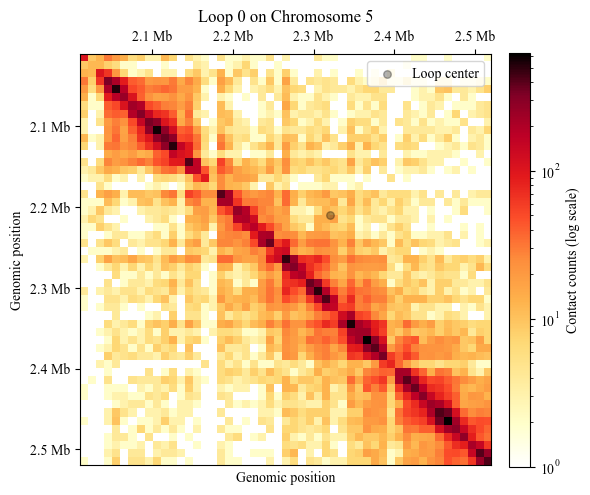

FDR: 0.0050184247991616
Loop size in Kb: 110.0
----


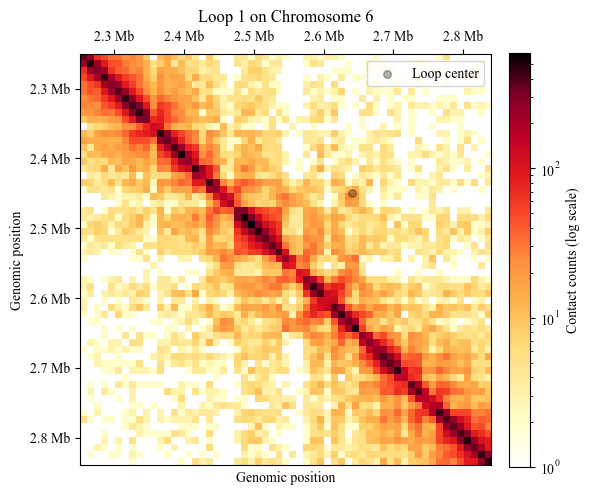

FDR: 0.0027518225281564
Loop size in Kb: 190.0
----


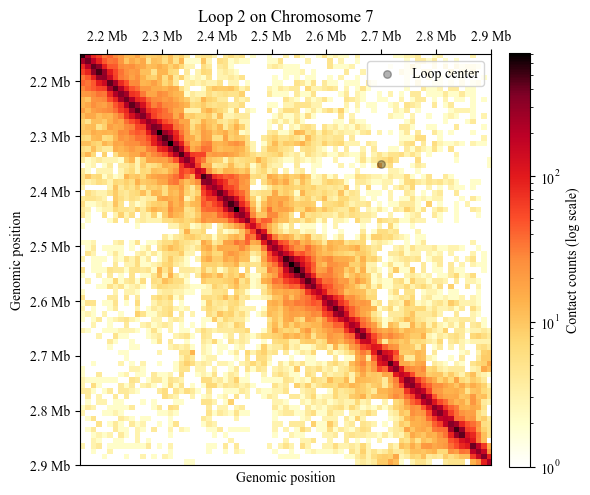

FDR: 0.0009887258686991
Loop size in Kb: 350.0
----


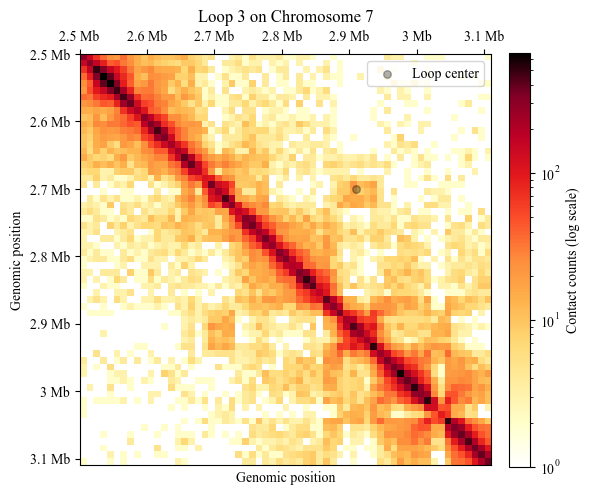

FDR: 2.101395234488379e-07
Loop size in Kb: 210.0
----


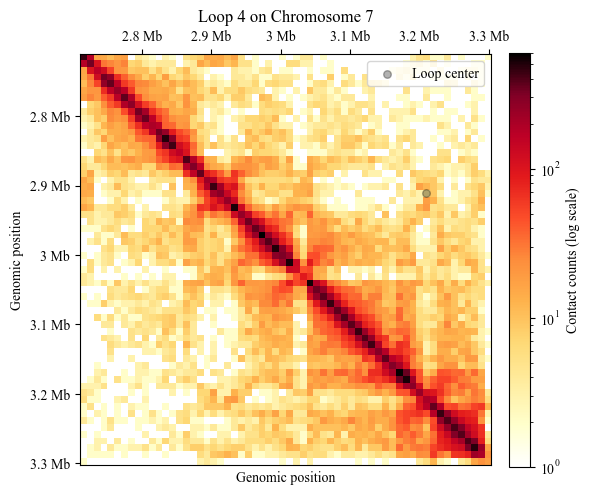

FDR: 9.498712594813162e-07
Loop size in Kb: 300.0
----


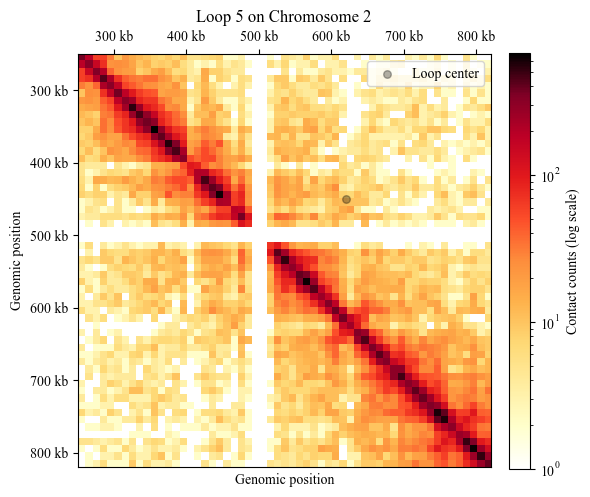

FDR: 0.0348643753399543
Loop size in Kb: 170.0
----


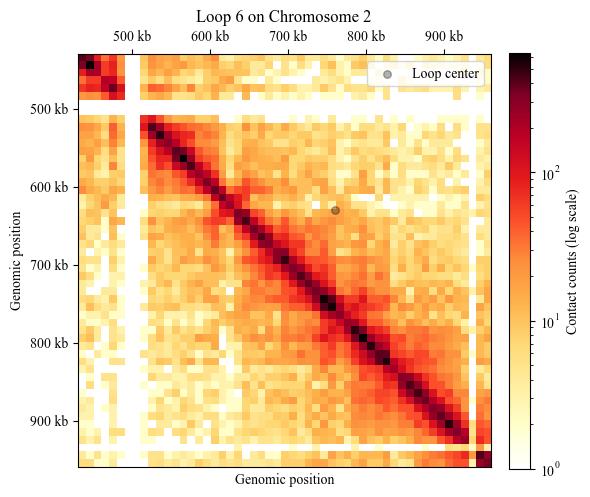

FDR: 0.0348643753399543
Loop size in Kb: 130.0
----


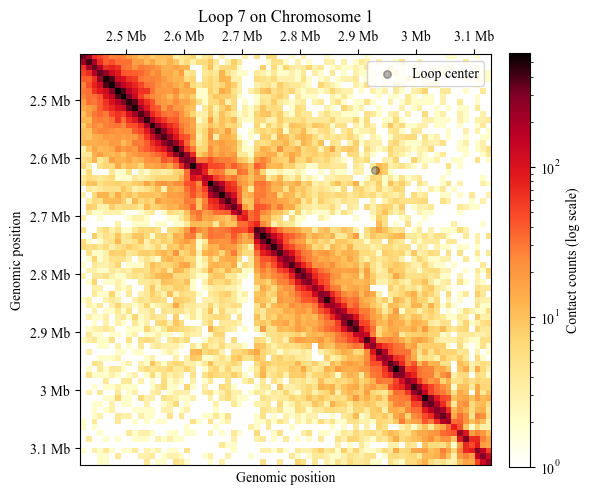

FDR: 0.0052219380583828
Loop size in Kb: 310.0
----


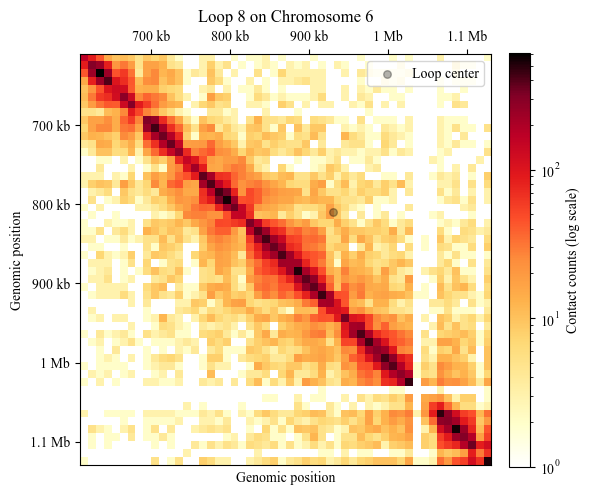

FDR: 0.01269701506239
Loop size in Kb: 120.0
----


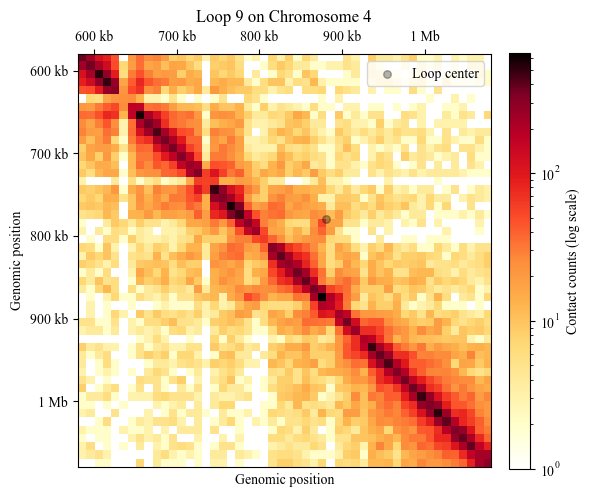

FDR: 0.0046945893029957
Loop size in Kb: 100.0
----


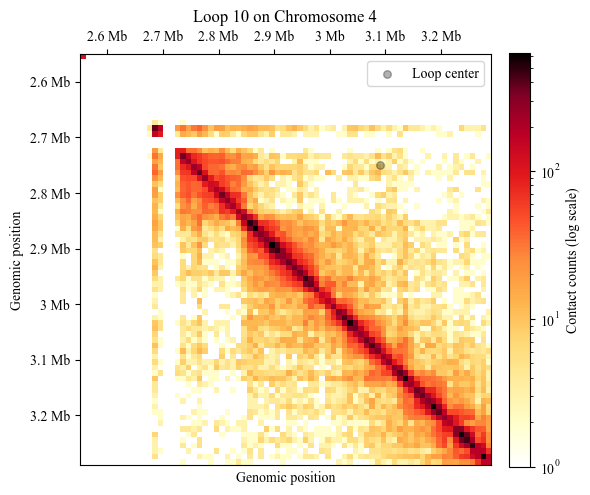

FDR: 0.0386258658613305
Loop size in Kb: 340.0
----


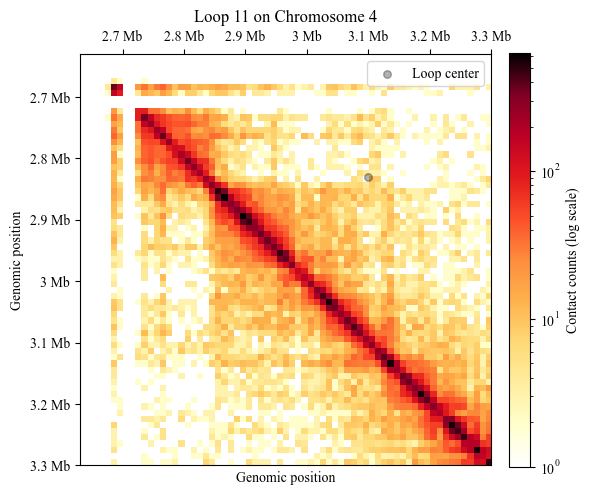

FDR: 0.0399372080225886
Loop size in Kb: 270.0
----


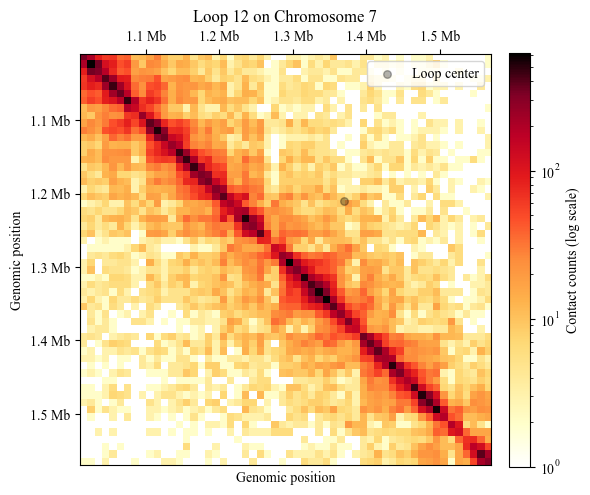

FDR: 0.0143865103803787
Loop size in Kb: 160.0
----


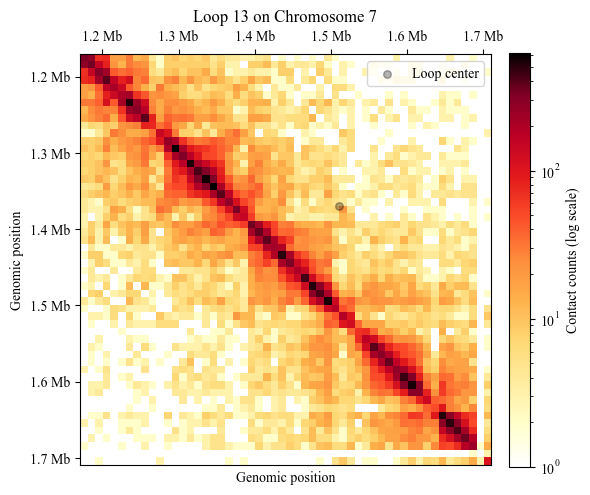

FDR: 0.0021093107288306
Loop size in Kb: 140.0
----


In [15]:

binsize = 10000  # matrix resolution

# For loop which goes through all the loops in the file and plots them 
for idx, loop in loops_10k_bedpe.iterrows():
    chrom = loop["chrom1"]
    start1 = loop["start1"]
    end1 = loop["end1"]
    start2 = loop["start2"]
    
    # Get the short chromosome label 
    chrom_index = chroms_to_keep_10k.index(chrom)
    chrom_label = short_labels[chrom_index]
    
    # Define region around loop
    pad = 200_000  # 200 kb upstream/downstream

    # Get chromosome size from cooler
    chrom_length = res_10k.chromsizes[chrom]

    # Defines the region
    # Start position is the smallest position of start1 and start2, and adds 200 kb upstream
    region_start = max(0, min(start1, start2) - pad)
    # End position is the largest position of end1 and start 2, and adds 200 kb downstream. 
    # Chrom_length ensures that the end coordinate is not further than the chromosome length
    region_end = min(chrom_length, max(end1, start2) + pad) 
    # String of the region
    region_str = f"{chrom}:{region_start}-{region_end}"
    extents = (region_start, region_end, region_end, region_start)
    
    # Fetch matrix (for the given region) from cooler 
    matrix = res_10k.matrix(balance=False).fetch(region_str)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(6,6))
    # Logarithmic scaling of the matrix
    norm = LogNorm(vmin=1, vmax=matrix.max())
    # Visualize the contact matrix with fall color map. x and y range match region defined above. 
    im = ax.matshow(matrix, cmap='fall', norm=norm, extent=extents)
    # Add colorbar indicating contact frequency
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Contact counts (log scale)')
    
    # Marking the loop center
    ax.scatter(start2, start1, color='black', s=30, alpha = 0.3, label='Loop center')
    ax.legend()
    
    # Axes labels and title
    ax.set_xlabel('Genomic position')
    ax.set_ylabel('Genomic position')
    ax.set_title(f"Loop {idx} on Chromosome {chrom_label}")

    # Use the tick formatting function from cooltools tutorial
    format_ticks(ax)

    plt.tight_layout()
    plt.show()

    # Print the FDR value and loop size for the given loop.
    fdr_value = loop["FDR"] 
    loop_size = loop["loop_size_kb"]
    print(f"FDR: {fdr_value}") 
    print(f"Loop size in Kb: {loop_size}")
    print("----")

# Adds annotation of neighbourhood

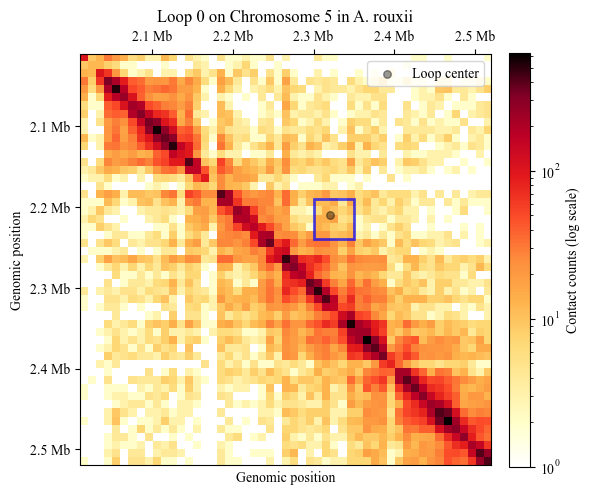

Loop 0 contact count: 17
Average background (5x5): 11.25
Loop appears enriched
FDR: 0.0050184247991616
Loop size in Kb: 110.0
----


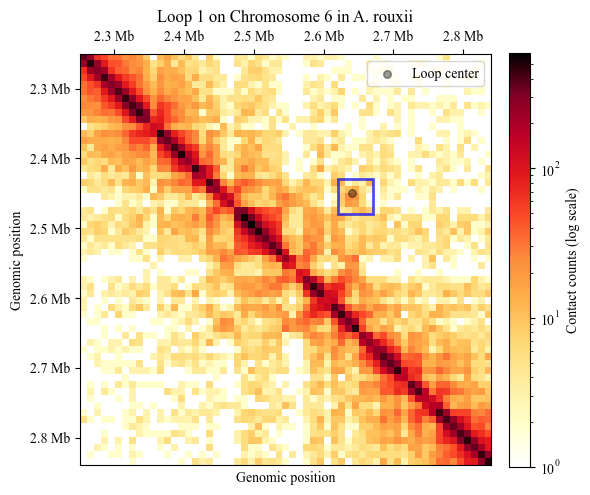

Loop 1 contact count: 21
Average background (5x5): 8.42
Loop appears enriched
FDR: 0.0027518225281564
Loop size in Kb: 190.0
----


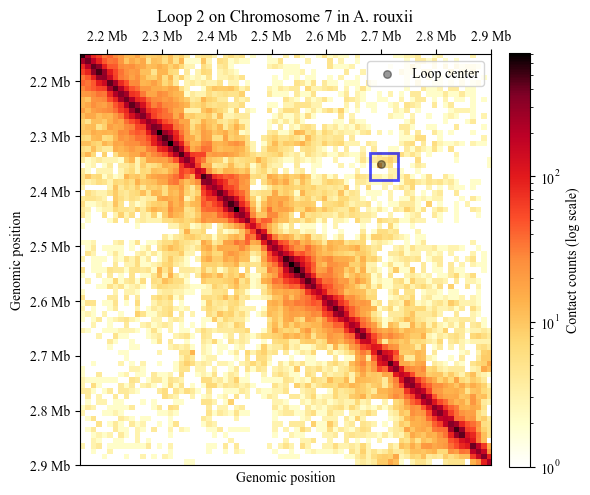

Loop 2 contact count: 4
Average background (5x5): 3.92
Loop appears enriched
FDR: 0.0009887258686991
Loop size in Kb: 350.0
----


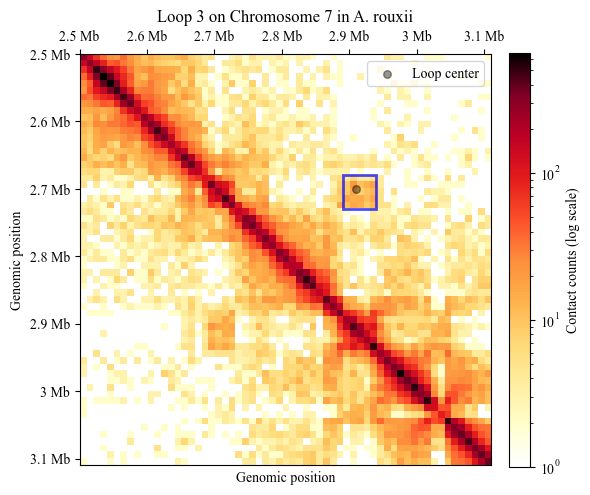

Loop 3 contact count: 8
Average background (5x5): 11.54
Loop does NOT appear enriched
FDR: 2.101395234488379e-07
Loop size in Kb: 210.0
----


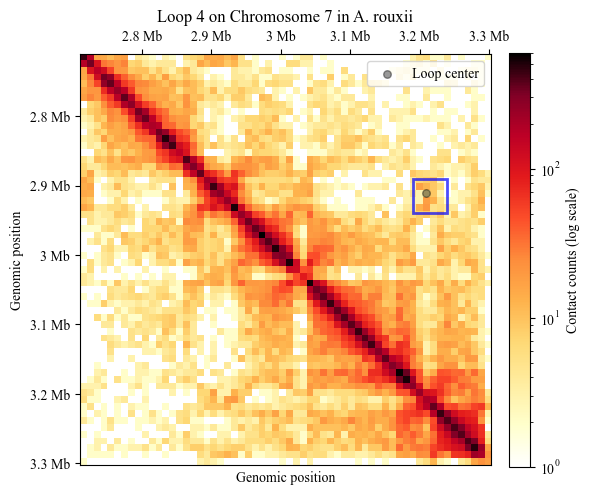

Loop 4 contact count: 4
Average background (5x5): 7.83
Loop does NOT appear enriched
FDR: 9.498712594813162e-07
Loop size in Kb: 300.0
----


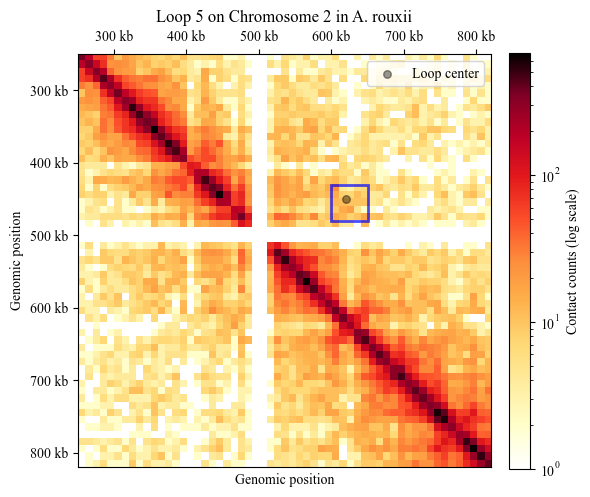

Loop 5 contact count: 10
Average background (5x5): 10.38
Loop does NOT appear enriched
FDR: 0.0348643753399543
Loop size in Kb: 170.0
----


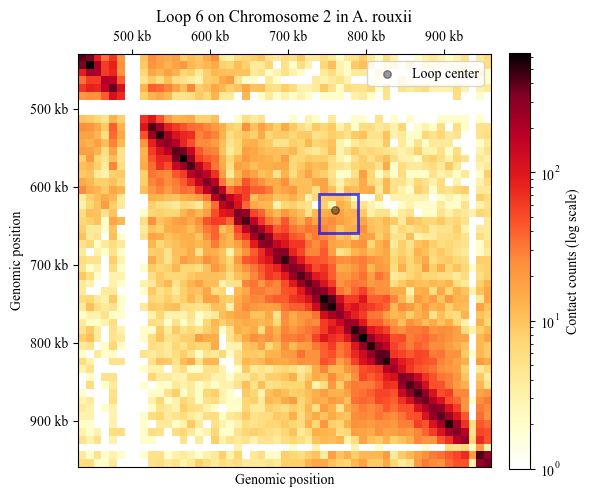

Loop 6 contact count: 17
Average background (5x5): 13.17
Loop appears enriched
FDR: 0.0348643753399543
Loop size in Kb: 130.0
----


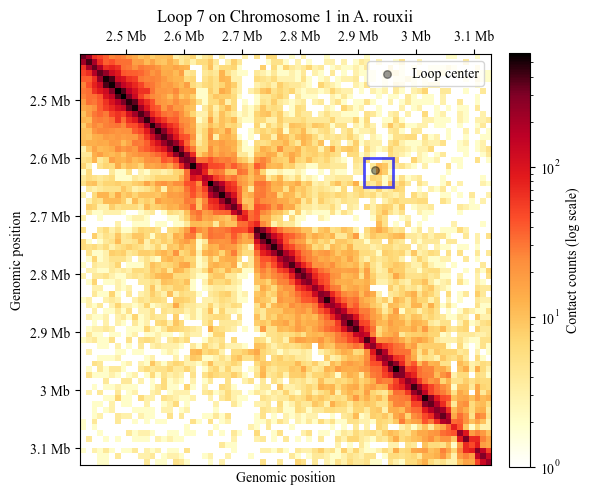

Loop 7 contact count: 12
Average background (5x5): 4.33
Loop appears enriched
FDR: 0.0052219380583828
Loop size in Kb: 310.0
----


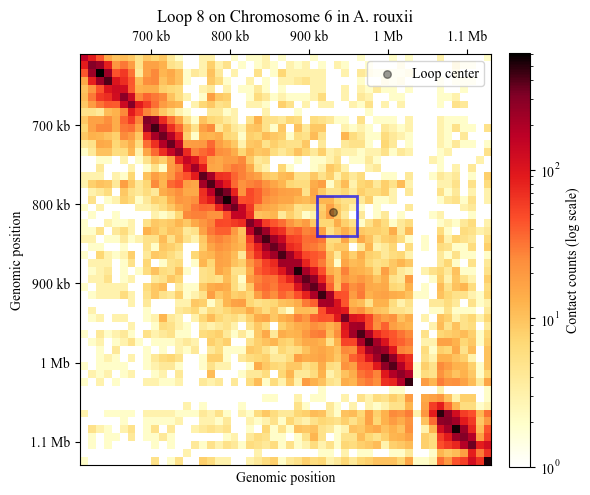

Loop 8 contact count: 9
Average background (5x5): 8.79
Loop appears enriched
FDR: 0.01269701506239
Loop size in Kb: 120.0
----


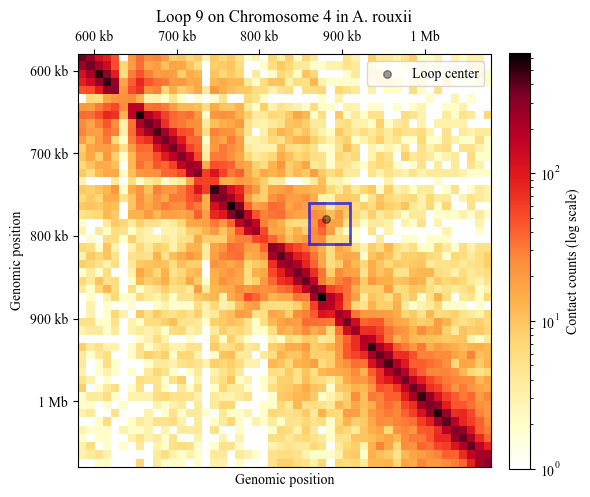

Loop 9 contact count: 17
Average background (5x5): 16.54
Loop appears enriched
FDR: 0.0046945893029957
Loop size in Kb: 100.0
----


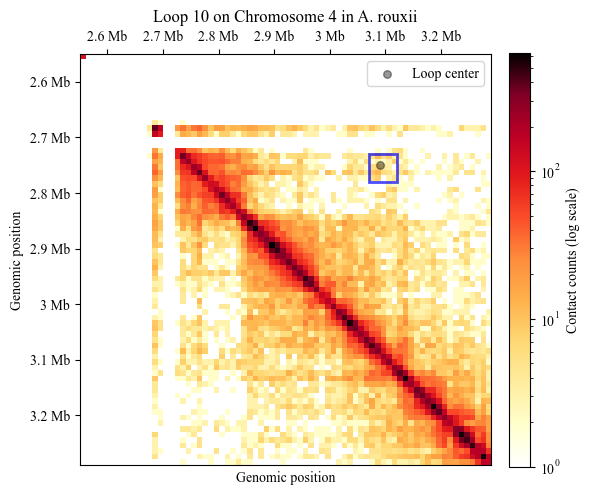

Loop 10 contact count: 4
Average background (5x5): 5.17
Loop does NOT appear enriched
FDR: 0.0386258658613305
Loop size in Kb: 340.0
----


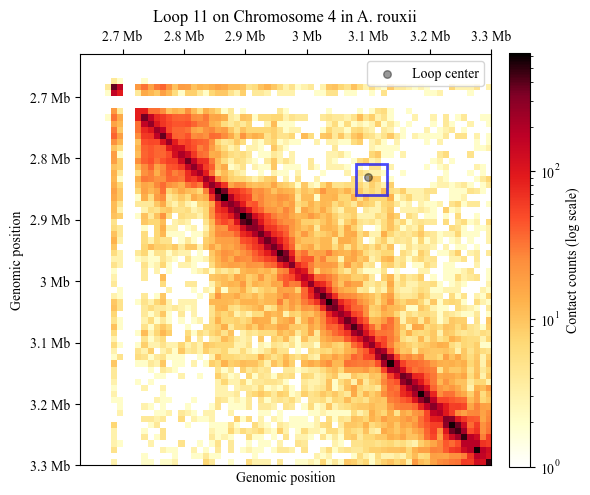

Loop 11 contact count: 9
Average background (5x5): 4.54
Loop appears enriched
FDR: 0.0399372080225886
Loop size in Kb: 270.0
----


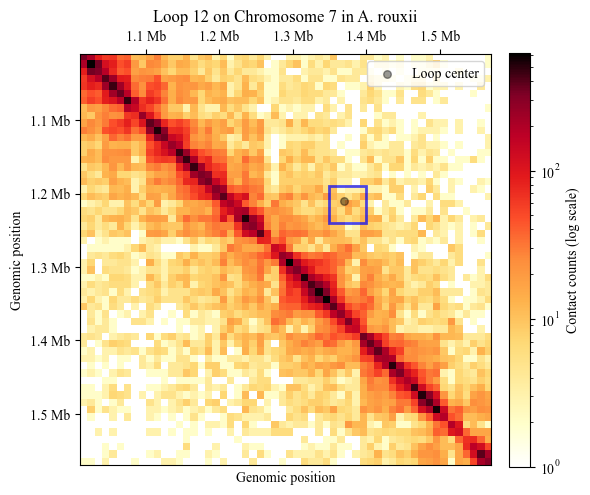

Loop 12 contact count: 18
Average background (5x5): 8.42
Loop appears enriched
FDR: 0.0143865103803787
Loop size in Kb: 160.0
----


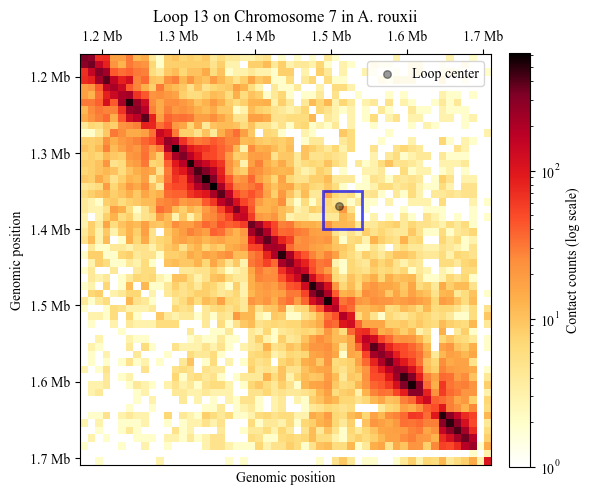

Loop 13 contact count: 20
Average background (5x5): 7.04
Loop appears enriched
FDR: 0.0021093107288306
Loop size in Kb: 140.0
----


In [16]:

binsize = 10000   # Matrix resolution
n = 2            # Neighborhood size (1->3x3, 2->5x5)

for idx, loop in loops_10k_bedpe.iterrows():

    chrom = loop["chrom1"]
    start1 = loop["start1"]
    end1 = loop["end1"]
    start2 = loop["start2"]

    # Chromosome label
    chrom_index = chroms_to_keep_10k.index(chrom)
    chrom_label = short_labels[chrom_index]

    # Region around loop
    pad = 200_000
    chrom_length = res_10k.chromsizes[chrom]

    region_start = max(0, min(start1, start2) - pad)
    region_end = min(chrom_length, max(end1, start2) + pad)

    region_str = f"{chrom}:{region_start}-{region_end}"

    # Fetch Hi-C matrix
    matrix = res_10k.matrix(balance=False).fetch(region_str)

    if matrix.size == 0:
        print(f"Loop {idx} skipped (empty matrix)")
        continue

    rows, cols = matrix.shape

    # Compute matrix bin indices
    i = int((start1 - region_start) // binsize)
    j = int((start2 - region_start) // binsize)

    # Skip loops outside matrix
    if i >= rows or j >= cols:
        print(f"Loop {idx} skipped (loop outside fetched matrix)")
        continue

    # Neighborhood bounds
    i_min = max(i - n, 0)
    i_max = min(i + n + 1, rows)

    j_min = max(j - n, 0)
    j_max = min(j + n + 1, cols)

    # Ensure full neighborhood exists
    if (i_max - i_min) < (2*n + 1) or (j_max - j_min) < (2*n + 1):
        print(f"Loop {idx} skipped (too close to edge)")
        continue

    neighborhood = matrix[i_min:i_max, j_min:j_max]

    if neighborhood.size == 0:
        print(f"Loop {idx} skipped (empty neighborhood)")
        continue

    # Center pixel
    center = matrix[i, j]

    # Background
    neighbors = np.delete(neighborhood.flatten(), n*(2*n+1) + n)
    avg_bg = neighbors.mean()

    # Rectangle genomic coordinates
    x0 = region_start + j_min * binsize
    y0 = region_start + i_min * binsize
    width = (j_max - j_min) * binsize
    height = (i_max - i_min) * binsize

    # Plotting
    fig, ax = plt.subplots(figsize=(6,6))

    norm = LogNorm(vmin=1, vmax=np.nanmax(matrix))

    extents = (region_start, region_end, region_end, region_start)

    im = ax.matshow(
        matrix,
        cmap="fall",
        norm=norm,
        extent=extents
    )

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        label="Contact counts (log scale)"
    )

    # Loop center
    ax.scatter(
        start2,
        start1,
        color="black",
        s=30,
        alpha=0.4,
        label="Loop center"
    )

    # Neighborhood square
    rect = patches.Rectangle(
        (x0, y0),
        width,
        height,
        linewidth=2,
        edgecolor="blue",
        facecolor="none",
        alpha=0.7
    )

    ax.add_patch(rect)

    ax.legend()

    ax.set_xlabel("Genomic position")
    ax.set_ylabel("Genomic position")

    ax.set_title(f"Loop {idx} on Chromosome {chrom_label} in A. rouxii")

    format_ticks(ax)

    plt.tight_layout()
    plt.show()

    # Enrichment results
    print(f"Loop {idx} contact count: {center}")
    print(f"Average background ({2*n+1}x{2*n+1}): {avg_bg:.2f}")

    if center > avg_bg:
        print("Loop appears enriched")
    else:
        print("Loop does NOT appear enriched")

    # Print the FDR value and loop size for the given loop.
    fdr_value = loop["FDR"] 
    loop_size = loop["loop_size_kb"]
    print(f"FDR: {fdr_value}") 
    print(f"Loop size in Kb: {loop_size}")
    print("----")

## Loops used in results

In [17]:
# Set fontsizes for result plots (to be the same across species)
mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

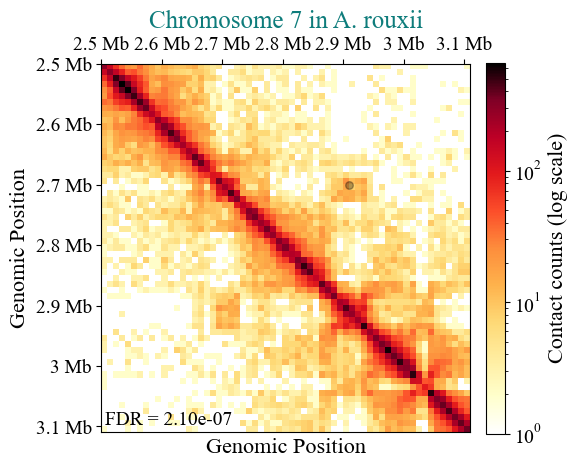

FDR: 2.101395234488379e-07
Loop size in Kb: 210.0


In [18]:
# Pick a loop
loop = loops_10k_bedpe.iloc[3]

chrom = loop["chrom1"]
start1 = loop["start1"]
end1 = loop["end1"]
start2 = loop["start2"]


# Finds the chromosome name in chroms_to_keep and then finds the chromosome in short_labels, finding the chromosome number
chrom_index = chroms_to_keep_10k.index(chrom)  
chrom_label = short_labels[chrom_index]  

chrom_index = chroms_to_keep_10k.index(chrom)
chrom_label = short_labels[chrom_index]
    
pad = 200_000  # 200 kb upstream/downstream
    # Get chromosome size from cooler
chrom_length = res_10k.chromsizes[chrom]
region_start = max(0, min(start1, start2) - pad)
region_end = min(chrom_length, max(end1, start2) + pad)
region_str = f"{chrom}:{region_start}-{region_end}"
extents = (region_start, region_end, region_end, region_start)

# Fetch the matrix for this region
# Assuming you have a cooler object called res_10k
matrix = res_10k.matrix(balance=False).fetch(region_str)

# Plotting
f, ax = plt.subplots(figsize=(6,6))
norm = LogNorm(vmin=1, vmax=matrix.max())

im = ax.matshow(matrix, cmap='fall', norm=norm, extent=extents)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Contact counts (log scale)')
cbar.ax.tick_params()

# Add loop dot
ax.scatter(start2, start1, color='black', s=30, alpha=0.3)

# Add FDR as text on the plot (bottom-left corner)
fdr_value = loop["FDR"]
ax.text(
    0.01, 0.01,
    f"FDR = {fdr_value:.2e}",
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="bottom"
)
# Axes labels
ax.set_xlabel('Genomic Position')
ax.set_ylabel('Genomic Position')

# Tick formatting function
format_ticks(ax)

ax.set_title(f"Chromosome {chrom_label} in A. rouxii", fontsize=18, color='#0E7C7BFF')


plt.tight_layout()
plt.show()
fdr_value = loop["FDR"] 
loop_size = loop["loop_size_kb"]
print(f"FDR: {fdr_value}") 
print(f"Loop size in Kb: {loop_size}")


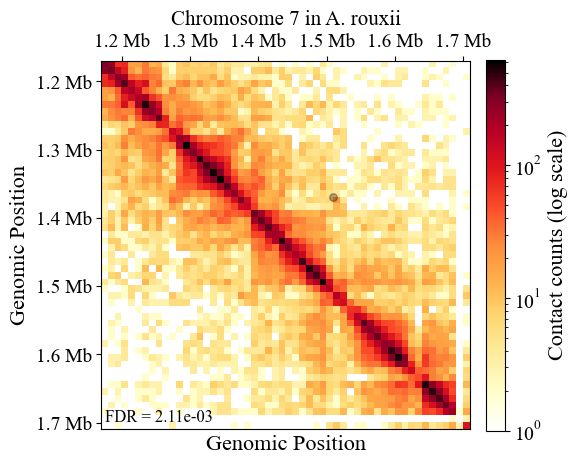

Loop contact count: 20
Local background: 6.0
Loop appears enriched
FDR: 0.0021093107288306
Loop size in Kb: 140.0


In [19]:
# Pick a loop
loop = loops_10k_bedpe.iloc[13]

chrom = loop["chrom1"]
start1 = loop["start1"]
end1 = loop["end1"]
start2 = loop["start2"]


# Finds the chromosome name in chroms_to_keep and then finds the chromosome in short_labels, finding the chromosome number
chrom_index = chroms_to_keep_10k.index(chrom)  
chrom_label = short_labels[chrom_index]  

chrom_index = chroms_to_keep_10k.index(chrom)
chrom_label = short_labels[chrom_index]
    
pad = 200_000  # 200 kb upstream/downstream
    # Get chromosome size from cooler
chrom_length = res_10k.chromsizes[chrom]
region_start = max(0, min(start1, start2) - pad)
region_end = min(chrom_length, max(end1, start2) + pad)
region_str = f"{chrom}:{region_start}-{region_end}"
extents = (region_start, region_end, region_end, region_start)
# Fetch the matrix for this region
# Assuming you have a cooler object called res_10k
matrix = res_10k.matrix(balance=False).fetch(region_str)

# Plot
f, ax = plt.subplots(figsize=(6, 6))
norm = LogNorm(vmin=1, vmax=matrix.max())

im = ax.matshow(matrix, cmap='fall', norm=norm, extent=extents)

# Colorbar
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Contact counts (log scale)')

# Add loop dot
ax.scatter(start2, start1, color='black', s=30, alpha = 0.3)

# Axes labels
ax.set_xlabel('Genomic Position')
ax.set_ylabel('Genomic Position')

# Optionally, use your tick formatting function
format_ticks(ax)

# Add FDR as text on the plot (bottom-left corner)
fdr_value = loop["FDR"]
ax.text(
    0.01, 0.01,
    f"FDR = {fdr_value:.2e}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="bottom"
)

ax.set_title(f"Chromosome {chrom_label} in A. rouxii", fontsize = 15)
plt.tight_layout()
plt.show()

binsize = 10000  # 10 kb
i = (start1 - region_start) // binsize
j = (start2 - region_start) // binsize

# Local 3x3 neighborhood around the loop
neighborhood = matrix[max(i-1,0):i+2, max(j-1,0):j+2]

# Center value (loop)
center = neighborhood[1,1]

# Average background (exclude center)
neighbors = np.delete(neighborhood.flatten(), 4)
avg_bg = neighbors.mean()

print(f"Loop contact count: {center}")
print(f"Local background: {avg_bg:.1f}")

if center > avg_bg:
    print("Loop appears enriched")
else:
    print("Loop does NOT appear enriched")

fdr_value = loop["FDR"] 
loop_size = loop["loop_size_kb"]
print(f"FDR: {fdr_value}") 
print(f"Loop size in Kb: {loop_size}")
